# EMG Preprocessing and Exploratory Data Analysis week 1 progress

## Dataset Overview

The NinaPro DB5 dataset was loaded and inspected for EMG signal preprocessing and exploratory analysis. The selected recording contains multichannel surface EMG (sEMG) data collected from 16 electrode channels over time.

### Data Dimensions
- EMG signal shape: `(130267, 16)`
- Stimulus label shape: `(130267, 1)`
- Repetition label shape: `(130267, 1)`

This indicates:
- 130267 time samples were recorded
- 16 EMG channels were captured simultaneously
- Each sample is associated with a gesture label (`stimulus`) and repetition identifier

---

## Signal Visualization

Raw EMG signals were plotted to inspect:
- amplitude variation
- baseline noise
- signal activity patterns

The raw signal contains both useful muscle activity and noise components.

---

## Bandpass Filtering

A bandpass filter in the range of `20–450 Hz` was applied to isolate the frequency range where meaningful muscle activity is typically present.

Purpose of filtering:
- remove low-frequency motion artifacts
- suppress high-frequency electrical noise
- preserve relevant EMG activity

---

## Rectification

The filtered EMG signal was rectified using absolute value transformation.

Purpose of rectification:
- convert negative amplitudes to positive values
- represent overall muscle activation magnitude
- simplify downstream analysis and model learning

---

## Window Segmentation

The processed EMG signal was segmented into fixed windows of `200 ms`.

Assuming a sampling frequency of `2000 Hz`:
- each window contains `400 samples`

Final window tensor shape:
- `(325, 400, 16)`

This corresponds to:
- 325 EMG windows
- 400 time samples per window
- 16 channels per sample

---

## Label Assignment

Each EMG window was assigned a gesture label using the dominant stimulus value within the corresponding time interval.

Observed gesture labels ranged from:
- `0–12`

Gesture `0` corresponds to the rest/no-activity state and contains the largest number of windows, which is expected in continuous EMG recordings.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat
from scipy.signal import butter, filtfilt

In [11]:
data = loadmat("../data/ninaprodb5_s1/S1_E1_A1.mat")

In [12]:
data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'emg', 'acc', 'stimulus', 'glove', 'subject', 'exercise', 'repetition', 'restimulus', 'rerepetition', 'age', 'circumference', 'frequency', 'gender', 'height', 'weight', 'laterality', 'sensor'])

In [13]:
emg = data['emg']
stimulus = data['stimulus']
repetition = data['repetition']

In [14]:
print(emg.shape)
print(stimulus.shape)
print(repetition.shape)

(130267, 16)
(130267, 1)
(130267, 1)


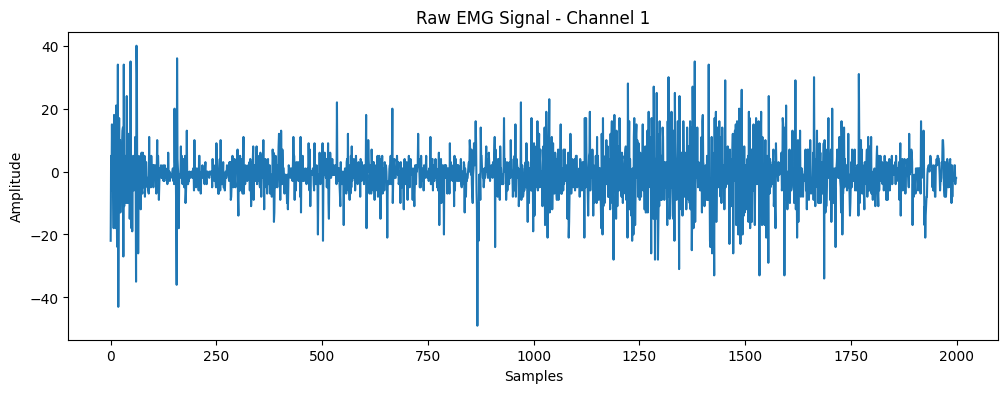

In [15]:
plt.figure(figsize=(12,4))
plt.plot(emg[:2000, 0])
plt.title("Raw EMG Signal - Channel 1")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

In [16]:
np.unique(stimulus)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=int8)

In [18]:
def bandpass_filter(signal, lowcut=20, highcut=450, fs=2000, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype='band')
    filtered = filtfilt(b, a, signal)

    return filtered

In [19]:
filtered_signal = bandpass_filter(emg[:, 0])

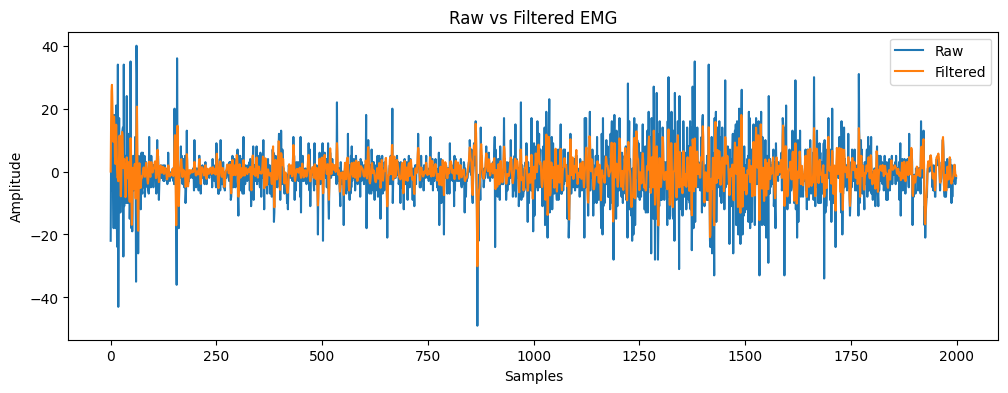

In [20]:
plt.figure(figsize=(12,4))

plt.plot(emg[:2000, 0], label="Raw")
plt.plot(filtered_signal[:2000], label="Filtered")

plt.title("Raw vs Filtered EMG")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.legend()
plt.show()

In [21]:
rectified_signal = np.abs(filtered_signal)

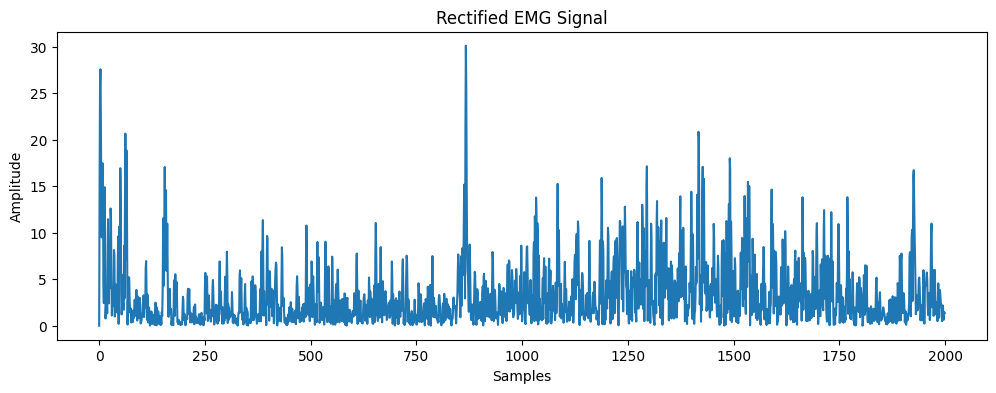

In [22]:
plt.figure(figsize=(12,4))

plt.plot(rectified_signal[:2000])

plt.title("Rectified EMG Signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.show()

In [23]:
window_size = 400

windows = []

for start in range(0, len(rectified_signal) - window_size, window_size):
    window = rectified_signal[start:start + window_size]
    windows.append(window)

windows = np.array(windows)

print(windows.shape)

(325, 400)


In [25]:
processed_emg = []

for channel in range(emg.shape[1]):

    # Take one channel
    signal = emg[:, channel]

    # Bandpass filter
    filtered = bandpass_filter(signal)

    # Rectification
    rectified = np.abs(filtered)

    processed_emg.append(rectified)

# Convert list to array and transpose
processed_emg = np.array(processed_emg).T

print(processed_emg.shape)

(130267, 16)


In [26]:
window_size = 400

windows = []
window_labels = []

for start in range(0, len(processed_emg) - window_size, window_size):

    # EMG window
    emg_window = processed_emg[start:start + window_size]

    # Corresponding stimulus segment
    stimulus_window = stimulus[start:start + window_size]

    # Flatten because stimulus shape is (n,1)
    stimulus_window = stimulus_window.flatten()

    # Find dominant gesture label in this window
    label = np.bincount(stimulus_window).argmax()

    windows.append(emg_window)
    window_labels.append(label)

windows = np.array(windows)
window_labels = np.array(window_labels)

print("Windows shape:", windows.shape)
print("Labels shape:", window_labels.shape)

Windows shape: (325, 400, 16)
Labels shape: (325,)


In [27]:
unique, counts = np.unique(window_labels, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Gesture {u}: {c} windows")

Gesture 0: 129 windows
Gesture 1: 15 windows
Gesture 2: 15 windows
Gesture 3: 15 windows
Gesture 4: 15 windows
Gesture 5: 16 windows
Gesture 6: 17 windows
Gesture 7: 18 windows
Gesture 8: 17 windows
Gesture 9: 18 windows
Gesture 10: 17 windows
Gesture 11: 17 windows
Gesture 12: 16 windows


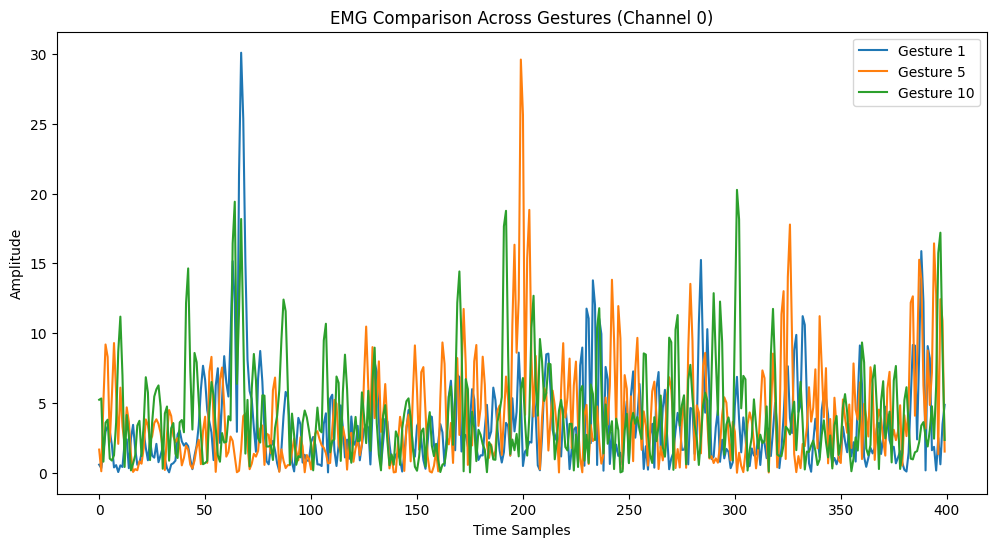

In [28]:
gesture_a = 1
gesture_b = 5
gesture_c = 10

# Find first window index for each gesture
idx_a = np.where(window_labels == gesture_a)[0][0]
idx_b = np.where(window_labels == gesture_b)[0][0]
idx_c = np.where(window_labels == gesture_c)[0][0]

# Select one EMG channel to visualize
channel = 0

# Extract windows
window_a = windows[idx_a][:, channel]
window_b = windows[idx_b][:, channel]
window_c = windows[idx_c][:, channel]

# Plot
plt.figure(figsize=(12,6))

plt.plot(window_a, label=f"Gesture {gesture_a}")
plt.plot(window_b, label=f"Gesture {gesture_b}")
plt.plot(window_c, label=f"Gesture {gesture_c}")

plt.title(f"EMG Comparison Across Gestures (Channel {channel})")
plt.xlabel("Time Samples")
plt.ylabel("Amplitude")

plt.legend()
plt.show()